### Intro

Notebook by Małgorzata Łazęcka (postdoc at Ewa Szczurek's lab) with modifications by Nick derived from Sam Fenske's notebooks.

#### Rotations

  - $Y^m \approx Z W^m$
  - $Y^m \approx ZRR^T W^m$
  - (for rotations $RR^T$)
  - $Z_{new} = ZR$ -> correlation with clinical features

#### Finding a rotation

If we can compute a correlation matrix for latent features (10) and clinical features (10):
  - canonical-correlation analysis, Kabsch algorithm, ... 
  - rotations based on SVD decomposition of the corralation matrix 
  - SVD $= U\Sigma V^T$, rotation $=U V^T$

#### Intuition behind using Pearson correlation for binary features

  - a measure of association between latent factors and for both binary and numeric variables?
  - a measure of association between latent factors and binary vars?
    - common scale
  - $r$ - Pearson corr
  - for normal variables: $t = r\sqrt{\frac{n-2}{1-r^2}}$ follows t-Student (when no correlation)
  - for normal and binary the same transformation gives usual two-sample t-test comparing two means

### Packages & functions

In [1]:
import pandas as pd
from scipy.stats import f_oneway
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
import os
import pathlib
import muon as mu
import mofax as mfx

import sys
sys.path.insert(0, '../lib/')

import common_data
import common_plots

In [2]:
%config InlineBackend.figure_format = 'retina'

In [3]:
pd.options.display.max_rows = 200

In [4]:
common_plots.setup_plotting()

In [ ]:
SAVE_DIR = common_data.DATA / '06_mofa'

In [6]:
def rotation(mat):

    H = mat
    U, S, Vt = np.linalg.svd(H)
    R = np.dot(Vt.T, U.T)

    return R

def pvalues_matrix(x, y):

    p1 = x.shape[1]
    p2 = y.shape[1]
    results = np.zeros((p1,p2))

    for i in range(p1):
        for j in range(p2):
            df = pd.DataFrame({
                'y': y[:,j],
                'x': x[:,i]
            })
            df['y'] = df['y'].astype('category')

            model = ols('x ~ y', data = df).fit()

            anova_result = sm.stats.anova_lm(model, typ=2)

            results[i,j] = anova_result['PR(>F)'][0]

    return results

def Fvalues_matrix(x, y):

    p1 = x.shape[1]
    p2 = y.shape[1]
    results = np.zeros((p1,p2))

    for i in range(p1):
        for j in range(p2):
            df = pd.DataFrame({
                'y': y[:,j],
                'x': x[:,i]
            })
            df['y'] = df['y'].astype('category')

            model = ols('x ~ y', data = df).fit()

            anova_result = sm.stats.anova_lm(model, typ=2)

            results[i,j] = anova_result['F'][0]

    return results

def dependence_matrix(x, y, metric = 'pearson'):

    p1 = x.shape[1]
    p2 = y.shape[1]
    results = np.zeros((p1,p2))

    for i in range(p1):
        for j in range(p2):
            x_tmp = x[~np.isnan(y[:,j]),i]
            y_tmp = y[~np.isnan(y[:,j]),j]

            if metric == 'pearson':
                results[i,j] = pearsonr(x_tmp, y_tmp)[0]
            if metric == 'spearman':
                results[i,j] = spearmanr(x_tmp, y_tmp)[0]
            if metric == 'Fstatistic':
                df = pd.DataFrame({
                    'y': y[:,j],
                    'x': x[:,i]
                })
                df['y'] = df['y'].astype('category')
                model = ols('x ~ y', data = df).fit()
                anova_result = sm.stats.anova_lm(model, typ=2)
                results[i,j] = (anova_result['F'][0])
            if metric == 'Fscaled':
                df1 = pd.DataFrame({
                    'y': y_tmp,
                    'x': x_tmp
                })
                df1['y'] = df1['y'].astype('category')
                model1 = ols('x ~ y', data = df1).fit()
                anova_result1 = sm.stats.anova_lm(model1, typ=2)

                df2 = pd.DataFrame({
                    'y': np.sort(y_tmp),
                    'x': np.sort(x_tmp)
                })
                df2['y'] = df2['y'].astype('category')
                model2 = ols('x ~ y', data = df2).fit()
                anova_result2 = sm.stats.anova_lm(model2, typ=2)
                results[i,j] = anova_result1['F'][0]/anova_result2['F'][0]
            if metric == 'Fscaled2':
                df1 = pd.DataFrame({
                    'y': y_tmp,
                    'x': x_tmp
                })
                df1['y'] = df1['y'].astype('category')
                model1 = ols('x ~ y', data = df1).fit()
                anova_result1 = sm.stats.anova_lm(model1, typ=2)
                var_x = np.var(x_tmp)*(x_tmp.shape[0] - 2)
                results[i,j] = anova_result1['F'][0]*(var_x/(var_x - 2))

            if metric == 'pvalue_transformed':
                df1 = pd.DataFrame({
                    'y': y_tmp,
                    'x': x_tmp
                })
                df1['y'] = df1['y'].astype('category')
                model1 = ols('x ~ y', data = df1).fit()
                anova_result1 = sm.stats.anova_lm(model1, typ=2)
                pval = anova_result1['PR(>F)'][0]
                pval_transformed = 1 + (1/0.1)*(pval - 0.1)
                results[i,j] = -np.log(pval_transformed)

    return results


def beta_matrix(x, y):
    p1 = x.shape[1]
    p2 = y.shape[1]
    results = np.zeros((p1,p2))
    for j in range(p2):
        mod = LogisticRegression(penalty='none', fit_intercept=False)
        x_tmp = x[~np.isnan(y[:,j]),:]
        y_tmp = y[~np.isnan(y[:,j]),j]
        mod.fit(x_tmp, y_tmp)
        results[:,j] = mod.coef_

    return results

def plot_pvals(pval, xticks):
    fig, axarr = plt.subplots(1,3)
    plt1 = axarr[0].imshow(pval, vmin=0, vmax=1)
    axarr[1].imshow(pval< 0.05/100)
    axarr[1].set_xticks(xticks)
    axarr[1].set_title('rejected: '+str(np.sum(pval< 0.05/100))+' ('+str(np.sum(np.diag(pval< 0.05/100)))+')')
    axarr[2].imshow(pval< 0.05)
    axarr[2].set_title('rejected: '+str(np.sum(pval< 0.05))+' ('+str(np.sum(np.diag(pval< 0.05)))+')')
    fig.colorbar(plt1, ax=axarr, location='bottom', shrink=0.5)
    plt.show()

def plot_pvals_sns(pval, factor_ticks, features_ticks):
    fig, axarr = plt.subplots(1,3, figsize=(10,3))
    sns.heatmap(-np.log10(pval.T), yticklabels=features_ticks, xticklabels=factor_ticks, ax=axarr[0]).set_title('-log10(pval)')
    sns.heatmap(pval.T < 0.05/100, yticklabels='', xticklabels=factor_ticks, ax=axarr[1],
                vmin=0, vmax=1).set_title('pval<0.05/100 ['+str(np.sum(pval< 0.05/100))+' ('+str(np.sum(np.diag(pval< 0.05/100)))+')]')
    sns.heatmap(pval.T < 0.05, yticklabels='', xticklabels=factor_ticks, ax=axarr[2],
                vmin=0, vmax=1).set_title('pval<0.05 ['+str(np.sum(pval< 0.05))+' ('+str(np.sum(np.diag(pval< 0.05)))+')]')
def plot_pvals_sns_2(pval, factor_ticks, features_ticks):
    fig, axarr = plt.subplots(1,3, figsize=(10,3))
    sns.heatmap(-np.log10(pval.T), yticklabels=features_ticks, xticklabels=factor_ticks, ax=axarr[0]).set_title('-log10(pval)')
    sns.heatmap(pval.T < 0.05/100, yticklabels='', xticklabels=factor_ticks, ax=axarr[1],
                vmin=0, vmax=1).set_title('pval<0.05/100 ['+str(np.sum(pval< 0.05/100))+']')
    sns.heatmap(pval.T < 0.05, yticklabels='', xticklabels=factor_ticks, ax=axarr[2],
                vmin=0, vmax=1).set_title('pval<0.05 ['+str(np.sum(pval< 0.05))+']')

In [7]:
def run_rotations_plots_outputs(x_rotated, y, factor_names, factor_rotated_names, factor_index, var_names, save=False, num='0'):

    y = np.array(y).astype('float')
    pval = pvalues_matrix(x_rotated, y)
    # plot_pvals_sns(pval, factor_names, var_names)
    dep = dependence_matrix(x_rotated, y, 'pearson')

    rotation_pearson = rotation(dep)
    new_x_pearson = np.dot(rotation_pearson, np.array(x_rotated).T).T
    pval = pvalues_matrix(new_x_pearson, y)
    plot_pvals_sns(pval, factor_rotated_names, var_names)

    factor_rotated = pd.DataFrame(new_x_pearson)
    factor_rotated.columns = factor_rotated_names
    factor_rotated.index = factor_index

    if save:
        np.savetxt('rotation_matrix_v'+str(num)+'.txt', rotation_pearson)
        factor_rotated.to_csv('factor_matrix_new_v'+str(num)+'.csv')

    return factor_rotated, rotation_pearson

### Data

In [8]:
factor = pd.read_csv(f'{SAVE_DIR}/factor_matrix.csv', index_col=0)
#clinical_categorical = pd.read_csv('data/clinical_categorical_features.csv', index_col=0)

In [9]:
clinical_categorical = common_data.get_sc_categorical_covariates().loc[factor.index]

In [10]:
clinical_categorical.shape

(269, 26)

In [11]:
factor.shape

(269, 10)

In [12]:
clinical_categorical.columns

Index(['Binary_outcome', 'CRRT_flag', 'Discharge_disposition', 'ECMO_flag',
       'Episode_category', 'Episode_etiology', 'Episode_is_cured', 'Ethnicity',
       'Sex', 'Global_cause_failure', 'Hemodialysis_flag',
       'Immunocompromised_flag', 'Norepinephrine_flag',
       'Pathogen_bacteria_detected', 'Pathogen_fungi_detected',
       'Pathogen_resistance_detected', 'Pathogen_virus_detected', 'Race',
       'Smoking_status', 'Tracheostomy_flag', 'Flow_clusters',
       'ScRNAseq_clusters', 'Pathogen_groups', 'Healthy_vs_NPC_vs_Pathogen',
       'VAP_is_cured_d7', 'VAP_onset_within_7d'],
      dtype='object')

### Feature transformations

#### Dummy - Pathogen_groups, Pathogen_groups_detailed

In [13]:
clinical_categorical['Pathogen_groups'].value_counts(dropna=False)

discard                               86
Early SARS-CoV-2                      35
NPC                                   25
Late SARS-CoV-2                       24
Gram+                                 23
Late SARS-CoV-2; Gram+                16
Gram-*                                15
Pseudomonas aeruginosa                10
Pseudomonas aeruginosa; SARS-CoV-2     9
Gram-*; Gram+                          9
Healthy                                9
Early SARS-CoV-2; Gram+                8
Name: Pathogen_groups, dtype: int64

In [14]:
pgd_tmp = pd.get_dummies(clinical_categorical['Pathogen_groups'])
pgd_tmp.columns = 'PGD_' + pgd_tmp.columns.astype(str)
clinical_categorical = clinical_categorical.assign(**pgd_tmp)

In [15]:
ec_tmp = pd.get_dummies(clinical_categorical['Episode_category'])
ec_tmp.columns = 'Episode_category_' + ec_tmp.columns.astype(str)
clinical_categorical = clinical_categorical.assign(**ec_tmp)

#### Assigning NA etc

In [16]:
clinical_categorical['VAP_is_cured_d7'] = (
    clinical_categorical['VAP_is_cured_d7'].astype(float).replace(-1, np.NaN)
)
clinical_categorical['VAP_onset_within_7d'] = (
    clinical_categorical['VAP_onset_within_7d'].astype(float).replace(-1, np.NaN)
)

In [17]:
clinical_categorical['VAP_is_cured_d7'].value_counts(dropna=False), clinical_categorical['VAP_onset_within_7d'].value_counts(dropna=False)

(NaN    228
 0.0     22
 1.0     19
 Name: VAP_is_cured_d7, dtype: int64,
 NaN    240
 1.0     25
 0.0      4
 Name: VAP_onset_within_7d, dtype: int64)

In [18]:
# clinical_categorical['VAP_is_cured_d7_1'] = 0
# clinical_categorical.loc[clinical_categorical['VAP_onset_within_7d']==1,'VAP_is_cured_d7_1'] = 1

# clinical_categorical['VAP_onset_within_7d_1'] = 0
# clinical_categorical.loc[clinical_categorical['VAP_onset_within_7d']==1,'VAP_onset_within_7d_1'] = 1

In [19]:
clinical_categorical['Sex_Female'] = clinical_categorical['Sex'].replace('Female', 1)
clinical_categorical['Sex_Female'] = clinical_categorical['Sex_Female'].replace('Male', 0)

In [20]:
# those that are ok:
# ECMO_flag
# Binary_outcome
# Pathogen_bacteria_detected

In [21]:
clinical_categorical['ECMO_flag'] = clinical_categorical['ECMO_flag'].replace('NA', np.nan).astype(float)

In [22]:
clinical_categorical['Binary_outcome'] = clinical_categorical['Binary_outcome'].replace('NA', np.nan).astype(float)

In [23]:
clinical_categorical['Pathogen_bacteria_detected'] = (
    clinical_categorical['Pathogen_bacteria_detected'].replace({
        'NA': np.nan,
        'False': 0.0,
        'True': 1.0
    }).astype(float)
)

In [24]:
clinical_categorical['Pathogen_virus_detected'] = (
    clinical_categorical['Pathogen_virus_detected'].replace({
        'NA': np.nan,
        'False': 0.0,
        'True': 1.0
    }).astype(float)
)

In [25]:
clinical_categorical['Immunocompromised_flag'] = (
    clinical_categorical['Immunocompromised_flag'].replace('NA', np.nan).astype(float)
)

In [26]:
clinical_categorical.loc[
    clinical_categorical['Episode_category'] == 'NA',
    'Episode_category_CAP'
] = np.nan

In [27]:
clinical_categorical['Healthy_vs_Pathogen'] = clinical_categorical['Healthy_vs_NPC_vs_Pathogen'].replace({
    'Healthy': 0.0,
    'NPC': np.nan,
    'Pathogen': 1.0,
    'discard': np.nan
}).astype(float)

In [28]:
clinical_categorical['Pathogen_bacteria_not_virus_detected'] = (
    clinical_categorical['Pathogen_bacteria_detected'].eq(1)
    & clinical_categorical['Pathogen_virus_detected'].eq(0)
).astype(float)
clinical_categorical.loc[
    clinical_categorical.Pathogen_bacteria_detected.isna(),
    'Pathogen_bacteria_not_virus_detected'
] = np.nan
clinical_categorical.loc[
    clinical_categorical.Pathogen_virus_detected.isna(),
    'Pathogen_bacteria_not_virus_detected'
] = np.nan

In [29]:
clinical_categorical['PGD_Early SARS-CoV-2'] = clinical_categorical['PGD_Early SARS-CoV-2'].astype(float)
clinical_categorical.loc[
    clinical_categorical.Pathogen_groups.eq('discard'),
    'PGD_Early SARS-CoV-2'
] = np.nan

In [30]:
var_names_5 = [
    'Binary_outcome',
    'VAP_is_cured_d7',
    'Episode_category_CAP',
    'Sex_Female',
    'ECMO_flag',
    'Immunocompromised_flag',
    'PGD_Early SARS-CoV-2',
    'Healthy_vs_Pathogen',
    'Pathogen_bacteria_detected',
    'Pathogen_bacteria_not_virus_detected'
]
y5 = clinical_categorical[var_names_5]

In [31]:
for col in y5.columns:
    print(col)
    print(y5[col].value_counts(dropna=False))
    print('---')

Binary_outcome
1.0    148
0.0    112
NaN      9
Name: Binary_outcome, dtype: int64
---
VAP_is_cured_d7
NaN    228
0.0     22
1.0     19
Name: VAP_is_cured_d7, dtype: int64
---
Episode_category_CAP
0.0    166
NaN     78
1.0     25
Name: Episode_category_CAP, dtype: int64
---
Sex_Female
0    170
1     99
Name: Sex_Female, dtype: int64
---
ECMO_flag
0.0    198
1.0     62
NaN      9
Name: ECMO_flag, dtype: int64
---
Immunocompromised_flag
0.0    193
1.0     67
NaN      9
Name: Immunocompromised_flag, dtype: int64
---
PGD_Early SARS-CoV-2
0.0    148
NaN     86
1.0     35
Name: PGD_Early SARS-CoV-2, dtype: int64
---
Healthy_vs_Pathogen
1.0    149
NaN    111
0.0      9
Name: Healthy_vs_Pathogen, dtype: int64
---
Pathogen_bacteria_detected
0.0    146
1.0    112
NaN     11
Name: Pathogen_bacteria_detected, dtype: int64
---
Pathogen_bacteria_not_virus_detected
0.0    193
1.0     65
NaN     11
Name: Pathogen_bacteria_not_virus_detected, dtype: int64
---


### Selecting subsets of features

In [32]:
var_names = ['Binary_outcome', 'ECMO_flag',
       'Episode_is_cured', 'Immunocompromised_flag', 'Norepinephrine_flag',
       'Pathogen_bacteria_detected', 'Pathogen_fungi_detected',
       'Pathogen_resistance_detected', 'Pathogen_virus_detected',
        'Pathogen_groups',
        'VAP_is_cured_d7', 'VAP_onset_within_7d',]
y = clinical_categorical[var_names]

### Rotations & correlations

In [33]:
factor_names = ['factor_'+str(i) for i in range(10)]
factor_rotated_names = ['factor_rotated_'+str(i) for i in range(10)]
x_rotated = np.array(factor)

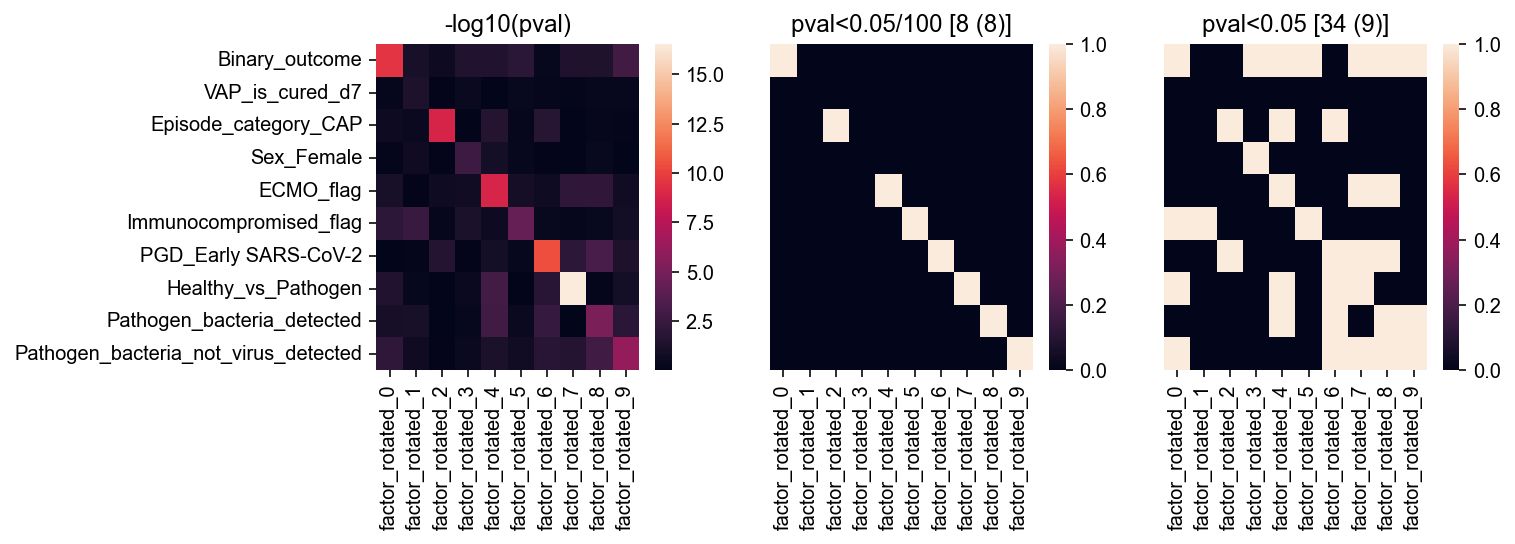

In [34]:
factor_rotated, rotation_pearson = run_rotations_plots_outputs(
    x_rotated,
    y5,
    factor_names,
    factor_rotated_names,
    factor.index,
    var_names_5,
    False,
    '5'
)

## Plot rotation objectives

In [35]:
FACTOR_ORDER = np.array([7, 10, 9, 6, 4, 1, 5, 3, 2, 8]) - 1

In [45]:
FACTOR_PRETTY_NAMES = {
    'Binary_outcome': 'Mortality: Died',
    'VAP_is_cured_d7': 'VAP cure in 7 days: Cure',
    'Episode_category_CAP': 'Episode category: CAP',
    'Sex_Female': 'Sex: Female',
    'ECMO_flag': 'ECMO: Yes',
    'Immunocompromised_flag': 'Immunocompromised: Yes',
    'PGD_Early SARS-CoV-2': 'Pathogen groups: Early SARS-CoV-2',
    'Healthy_vs_Pathogen': 'Healthy / NPC / Viral, bacterial or mixed:\n    Viral, bacterial or mixed',
    'Pathogen_bacteria_detected': 'Bacteria detected: Yes',
    'Pathogen_bacteria_not_virus_detected': 'Bacteria only detected: Yes'
}

In [46]:
PALETTE = ['#b70e11', '#00459b', '#dddddd']

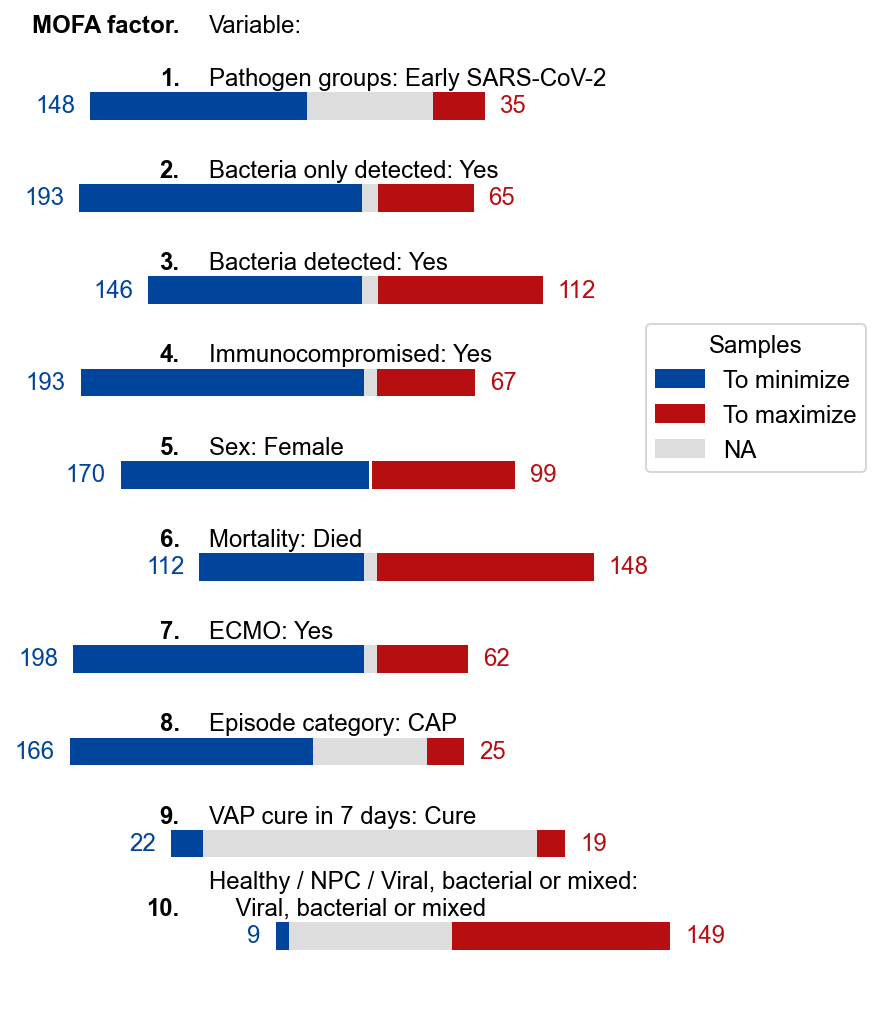

In [48]:
fig, ax = plt.subplots(figsize=(6, 7), constrained_layout=True)
BAR_H = 0.3

ax.annotate(
    'MOFA factor.',
    xy=(-130, -0.8),
    size=12,
    ha='right',
    fontweight='bold'
)
ax.annotate(
    'Variable:',
    xy=(-110, -0.8),
    size=12
)

for i, factor in enumerate(pd.Series(var_names_5)[FACTOR_ORDER]):
    counts = y5[factor].value_counts(dropna=False)
    if np.nan in counts:
        n_na = counts[np.nan]
    else:
        n_na = 0
    ax.barh(i, width=n_na, left=n_na / -2, height=BAR_H, color=PALETTE[2])
    ax.barh(i, width=counts[1.0], left=n_na / 2, height=BAR_H, color=PALETTE[0])
    ax.barh(i, width=-counts[0.0], left=n_na / -2, height=BAR_H, color=PALETTE[1])
    if n_na == 0:
        ax.plot([0, 0], [i - BAR_H / 2, i + BAR_H / 2], c='w')
    ax.annotate(
        FACTOR_PRETTY_NAMES[factor],
        xy=(-110, i - BAR_H / 2),
        xytext=(0, 2),
        textcoords='offset pixels',
        size=12,
        va='bottom'
    )
    ax.annotate(
        str(i + 1) + '.',
        xy=(-130, i - BAR_H / 2),
        xytext=(0, 2),
        textcoords='offset pixels',
        size=12,
        ha='right',
        va='bottom',
        fontweight='bold'
    )
    ax.annotate(
        str(counts[1.0]),
        xy=(counts[1.0] + n_na / 2, i),
        xytext=(15, 0),
        textcoords='offset pixels',
        size=12,
        color=PALETTE[0],
        va='center'
    )
    ax.annotate(
        str(counts[0.0]),
        xy=(-counts[0.0] - n_na / 2, i),
        xytext=(-15, 0),
        textcoords='offset pixels',
        size=12,
        color=PALETTE[1],
        va='center',
        ha='right'
    )
ax.yaxis.set_inverted(True)
ax.set_ylim(9.8, -1)
ax.spines[['left', 'top', 'right', 'bottom']].set_visible(False)
ax.set_yticks([])
ax.set_xticks([])
ax.legend(
    handles=[
        mpl.patches.Patch(
            color=PALETTE[1],
            label='To minimize'
        ),
        mpl.patches.Patch(
            color=PALETTE[0],
            label='To maximize'
        ),
        mpl.patches.Patch(
            color=PALETTE[2],
            label='NA'
        )
    ],
    loc='upper left',
    bbox_to_anchor=(0.9, 0.7),
    title='Samples',
    fontsize=12,
    title_fontsize=12
)
fig.savefig('00_plots/02_rotation_objectives.pdf')

In [34]:
os.makedirs('02_mofa_rotations', exist_ok=True)

In [35]:
np.savetxt('02_mofa_rotations/rotation_matrix.txt', rotation_pearson)
factor_rotated.to_csv('02_mofa_rotations/factor_matrix.csv')

In [39]:
mdata = mu.read_h5mu(SAVE_DIR / '01_mofa_fitted.h5mu')

## Explained variance

Define our function for rotations

In [40]:
def calculate_r2(mofa_data):
    """
    Function adapted from https://github.com/bioFAM/mofax/blob/master/mofax/core.py#L968
    to support calculating R2 for MOFA model
    without hdf5 MOFA file.

    We use for the rotated MOFA
    """
    result = []
    # iterate over factors
    for i in range(mofa_data.obs.shape[1]):
        # iterate over views
        for view in mofa_data.mod.keys():
            r2 = mfx.calculate_r2(
                Z=mofa_data.obs.T.iloc[[i]].loc[:, mofa_data.obsm[view]].to_numpy(),
                W=mofa_data.var.T.iloc[[i]].loc[:, mofa_data.varm[view]].to_numpy(),
                Y=mofa_data.mod[view].X
            )
            result.append((i, view, r2))
    result = pd.DataFrame(result, columns=['Factor', 'View', 'R2'])
    result.Factor = 'Factor' + (result.Factor + 1).astype(str)
    return result

A function from Małgorzata Łazęcka to compute the variance explained in the view.

In [41]:
def calculate_r2_view(mofa_data):
    result = []
    for view in mofa_data.mod.keys():
        r2 = mfx.calculate_r2(
            Z=mofa_data.obs.T.loc[:, mofa_data.obsm[view]].to_numpy(),
            W=mofa_data.var.T.loc[:, mofa_data.varm[view]].to_numpy(),
            Y=mofa_data.mod[view].X
        )
        result.append((view, r2))
    result = pd.DataFrame(result, columns=['View', 'R2'])
    return result

### Rotated

In [42]:
new_weights = (rotation_pearson @ mdata.varm['LFs'].T).T

In [43]:
mdata_new = mdata.copy()

In [44]:
mdata_new.var[:] = new_weights

In [45]:
mdata_new.obs[:] = factor_rotated.to_numpy()

In [46]:
new_product = (mdata_new.obs.to_numpy() @ mdata_new.var.T.to_numpy())

In [47]:
old_product = mdata.obs.to_numpy() @ mdata.var.T.to_numpy()

In [48]:
np.allclose(old_product, new_product)

True

In [49]:
mdata_new.var.to_csv('02_mofa_rotations/feature_weights.csv')

In [50]:
expl_var_view = calculate_r2_view(mdata_new)

In [51]:
expl_var = calculate_r2(mdata_new)

In [52]:
expl_var_view.View = pd.Categorical(expl_var_view.View, categories=[
    'cell_type_abundance',
    'NUPR1+ Macs_sc',
    'MRC1+C1QA+_sc',
    'MRC1+C1QA-_sc',
    'Classical monocytes-2 IL1B_sc',
    'DC2_sc',
    'CD4 T cells_sc',
    'CD8 T cells_sc',
    'gdT cells_sc'
])
expl_var_view = expl_var_view.sort_values('View')

In [53]:
FACTOR_ORDER = np.array([7, 10, 9, 6, 4, 1, 5, 3, 2, 8]) - 1

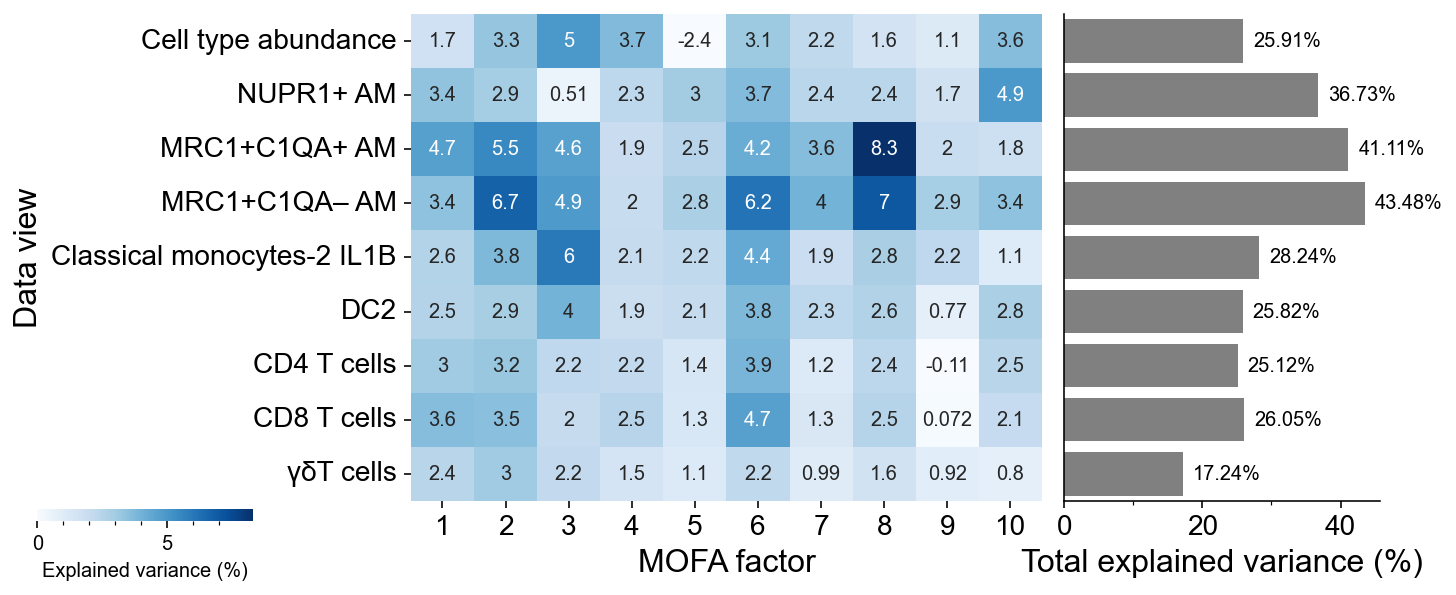

In [54]:
fig, axes = plt.subplots(
    figsize=(10, 4),
    constrained_layout=True,
    ncols=2,
    sharey=False,
    gridspec_kw=dict(
        width_ratios=[2, 1]
    )
)

cbar_ax = fig.add_axes((0.0, 0.0, 0.08, 0.02))

ax = axes[0]

expl_var_hm = expl_var.pivot_table(columns='Factor', index='View', values='R2')
factors = [f'Factor{i}' for i in range(1, 11)]
expl_var_hm = expl_var_hm[factors].loc[expl_var_view.View]
sns.heatmap(
    expl_var_hm.iloc[:, FACTOR_ORDER],
    cmap='Blues',
    annot=True,
    ax=ax,
    cbar_ax=cbar_ax,
    cbar_kws=dict(
        label='Explained variance (%)',
        orientation='horizontal',
    ),
    vmin=0
)
ax.set_xticklabels(list(range(1, 11)))
ax.set_xlabel('MOFA factor', size=16)
ax.set_ylabel('Data view', size=16)
ax.tick_params(labelsize=14)

ax.set_yticklabels([common_plots.CELL_TYPES_DISPLAY.get(x, x) for x in [
    'Cell type abundance',
    'NUPR1+ Macs',
    'MRC1+C1QA+',
    'MRC1+C1QA-',
    'Classical monocytes-2 IL1B',
    'DC2',
    'CD4 T cells',
    'CD8 T cells',
    'gdT cells'
]])

ax = axes[1]

plot_df = expl_var_view
sns.barplot(
    data=plot_df,
    x='R2',
    y='View',
    ax=ax,
    color='gray'
)
ax.set_yticks([])
ax.bar_label(ax.containers[0], padding=5, fmt='%.2f%%')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('Total explained variance (%)', size=16)
ax.set_ylabel('', size=16)
ax.tick_params(labelsize=14)
ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(20))
ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(10))
cbar_ax.set_xticks([1, 2, 3, 4, 5, 6, 7], minor=True)

# fig.axes[2].set_adjustable('box')
fig.axes[2].set_position((0.02, 0.11, 0.15, 0.02))
fig.savefig('00_plots/02_expl_var.pdf')

In [57]:
print(f'Average explained variance across views: {expl_var_view.R2.mean():.2f}%')

Average explained variance across views: 29.97%
